In [35]:
from spin_lattices import (
    KagomeLattice,
    SpinLattice,
    ChainLattice,
    SquareLattice,
    TriangleLattice,
)
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import networkx as nx
import numpy as np
from typing import Callable
import torch
import numpy.typing as npt
import lattice_symmetries as ls
from typing import Any, Optional, Union, Dict, Tuple
from loguru import logger
from collections import namedtuple
from torch import Tensor
import torch.nn as nn
from misc_utils import make_unpacked_configurations
import io
from contextlib import redirect_stderr
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from nqs_playground_helpers import (
    SamplingOptions,
    split_into_batches,
    safe_exp,
    sample_exactly,
    sample_full,
    forward_with_batches,
)
from scipy.sparse import csr_matrix, coo_matrix, diags
from scipy.sparse.csgraph import connected_components
import sys
from kagome_cnn import KagomeCNNRegression
from torch.nn.utils.convert_parameters import parameters_to_vector, vector_to_parameters
import time
from scipy.optimize import minimize
from vmc_amplitude import almost_true_relsigns
from vmc_vs_lbfgs import AmplitudeOptimizer
import fire
from my_stopwatch import stopwatch
from vmc_vs_lbfgs_2023_08_02 import LogProbDenseNet
from misc_utils import make_unpacked_configurations

from slater_determinant import SlaterDeterminant, Initializer
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from misc_utils import torch_overlap as overlap
import itertools

logger.remove()
logger.add(sys.stderr, level="INFO")

5

In [36]:
class SlaterDet(nn.Module):
    def __init__(
        self,
        system: SpinSystem,
        initialization: str | Initializer = "orthogonal",
        postprocessor=None,
    ):
        super().__init__()
        self.det = SlaterDeterminant(
            lattice=system.lattice,
            basis=system.canonical_basis,
            initialization=initialization,
            sign_cache_dir=Path("signs_cache"),
        )
        self.system = system
        self.postprocessor = postprocessor

    def forward(self, states: torch.Tensor | npt.NDArray):
        if isinstance(states, np.ndarray):
            states = torch.from_numpy(states.astype(np.int64))
        indices = self.system.canonical_basis.index(
            states.detach().numpy().astype(np.uint64)
        )
        assert isinstance(indices, np.ndarray)
        indices = torch.from_numpy(indices.astype(np.int64))
        ret = ((self.det.forward(indices))).view(-1, 1)
        if self.postprocessor is not None:
            return self.postprocessor(ret)
        return ret

In [37]:
@torch.no_grad()
def evaluate(system: SpinSystem, model: nn.Module):
    eval_set = torch.from_numpy(system.canonical_basis.states.astype(np.int64))
    log_probs = model(eval_set).view(-1)
    amplitudes = torch.exp(log_probs * 0.5)
    true_amplitudes = torch.from_numpy(
        np.abs(system.get_ground_state_coeffs(eval_set.detach().numpy())).astype(
            np.float32
        )
    )
    return overlap(amplitudes, true_amplitudes)

In [38]:
def pretrain(
    system: SpinSystem,
    model: nn.Module,
    train_size=1000,
    batch_size=32,
    lr=1e-3,
    epochs=10,
    evaluate_system: SpinSystem | None = None,
):
    true_probs = (
        np.abs(system.get_ground_state_coeffs(system.canonical_basis.states)) ** 2
    )

    train_set = np.random.choice(
        system.canonical_basis.states.astype(np.int64),
        p=true_probs,
        size=train_size,
        replace=True,
    )
    X = torch.from_numpy(train_set)
    Y = (
        torch.from_numpy(
            np.log(np.abs(system.get_ground_state_coeffs(train_set).astype(np.float32)))
        )
        * 2
    )

    dataset = TensorDataset(X, Y)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Learning rate

    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            # Get the inputs and move them to the specified device
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(
                outputs, labels.view(-1, 1)
            )  # Reshape labels to match output shape
            loss.backward()
            optimizer.step()

            # Print statistics
            running_loss += loss.item()

        logger.info(f"{running_loss=}")
        logger.info(
            f"Overlap: {overlap(torch.exp(model(X).view(-1) * 0.5), torch.exp(Y * 0.5))}"
        )
        if evaluate_system is not None:
            logger.info(f"{evaluate(evaluate_system, model)=}")
        # Print average loss per epoch
        # print(f"Epoch {epoch + 1} loss: {running_loss / len(dataloader)}")
        # print(f"Overlap: {overlap(torch.exp(model(X).view(-1)), torch.exp(Y))}")
    return model

In [39]:
make_unpacked_configurations(1, 3)

array([1, 0, 0], dtype=uint64)

In [40]:
configs = np.array([[1, -1, 1], [1, 1, -1], [-1, -1, 1], [1, -1, -1]])
n_cols = configs.shape[1]
pairwise_products = np.multiply.outer(configs.T, configs.T)
pairwise_products = np.triu(pairwise_products, k=1)  # Keep only upper triangular part
pairwise_products = pairwise_products.reshape(-1, n_cols**2)[
    :, :: n_cols + 1
]  # Extract unique products
result = np.concatenate((configs, pairwise_products), axis=1)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 4 and the array at index 1 has size 16

In [41]:
class LogProbDenseNetPairwiseXor(nn.Module):
    def __init__(
        self,
        system: SpinSystem,
        n_hidden: int = 100,
        hidden_layers=1,
        scaling=1.0,
        xor_pairs=(np.array([]), np.array([])),
    ):
        super().__init__()
        self.system = system
        self.n_hidden = n_hidden
        self.hidden_layers = hidden_layers
        layers = [
            nn.Linear(system.number_spins + len(xor_pairs[0]), n_hidden),
            nn.ReLU(),
        ]
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(n_hidden, n_hidden))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(n_hidden, 1))
        self.net = nn.Sequential(*layers)
        self.scaling = scaling
        self.xor_pairs = xor_pairs

    def forward(self, x: Tensor) -> Tensor:
        configs = 1 - 2 * make_unpacked_configurations(
            x, self.system.number_spins
        ).astype(np.float32)
        products = configs[:, self.xor_pairs[0]] * configs[:, self.xor_pairs[1]]

        configs = np.concatenate((configs, products), axis=1)
        return self.scaling * self.net(torch.from_numpy(configs))

In [33]:
pairs = tuple(map(np.array, zip(*system.lattice.edges_to_kind.keys())))
pairs

(array([ 0,  1,  0,  1,  3,  5,  6,  6,  4,  2,  5,  6,  8, 10, 11, 11,  9,
         7, 10, 11, 13,  1, 14, 12,  2, 15, 15,  7, 16, 16, 16, 12, 17, 17,
        17, 15]),
 array([ 1,  2,  3,  3,  5,  6,  4,  7,  7,  4,  8,  8, 10, 11,  9, 12, 12,
         9, 13, 13,  0, 14,  2, 14, 15,  0,  4, 16,  3,  5,  9, 17,  8, 10,
        14, 13]))

In [34]:
stopwatch.reset()
lattice = KagomeLattice(2, 3)
# transfer_source_lattice = KagomeLattice(2, 2)
J2 = 1

system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=J2,
    use_symmetries=False,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
)
logger.info(f"System: {system.get_cache_id()}")


# transfer_source_system = HeisenbergJ1J2(
#     lattice=transfer_source_lattice,
#     J1=1,
#     J2=J2,
#     use_symmetries=False,
#     spin_inversion=None,
#     ground_state_cache_dir=Path("groundstates"),
# )
# transfer_source_system.get_eigenstates(1)


energy, _ = system.get_eigenstates(1)
# pairs = tuple(
#     map(np.array, zip(*itertools.combinations(range(system.number_spins), 2)))
# )
pairs = tuple(map(np.array, zip(*system.lattice.edges_to_kind.keys())))

# log_prob_fn = LogProbDenseNetPairwiseXor(
#     system, n_hidden=512, hidden_layers=1, xor_pairs=pairs
# )
log_prob_fn = LogProbDenseNet(system, n_hidden=512, hidden_layers=1)

# log_prob_fn = KagomeCNNRegression(lattice, hidden_channels1=128, hidden_channels2=128)
# print(evaluate(transfer_source_system, log_prob_fn))
# pretrain(
#     transfer_source_system,
#     log_prob_fn,
#     train_size=10000,
#     epochs=2,
#     batch_size=64,
#     lr=1e-2,
#     evaluate_system=system,
# )
# log_prob_fn = SlaterDet(system, postprocessor=lambda x: torch.log(torch.abs(x)))
# print(f"{evaluate(transfer_source_system, log_prob_fn)=}")
# print(f"{evaluate(system, log_prob_fn)=}")

logger.info(f"True energy: {energy[0]}")

writer = SummaryWriter(
    log_dir=(
        f"experiments/{datetime.now().strftime('%Y_%m_%d')}/{datetime.now().strftime('%H_%M_%S')}"
    )
)

optimizer = AmplitudeOptimizer(
    system=system,
    log_prob_fn=log_prob_fn,
    method="L-BFGS-B",
    maxiter=100000,
    batch_size=8096,
    tb_writer=writer,
    full_spin_loss_weight=0,
    full_energy_weight=1,
    # clip_grad_value=0.02,
    # clip_grad_norm=0.02,
    # clip_grad_norm_type='inf',
    # annealing_steps=0, #240,
    # initial_temp=2,
    # sign_noise_annealing_steps=10,
    # sign_noise_initial_eps=0.2,
)
try:
    r = optimizer.optimize_scipy()
    print(r)
finally:
    logger.info(str(stopwatch))

[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-09 21:03:28.157 | INFO     | __main__:<module>:14 - System: HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None
2023-08-09 21:03:28.164 | INFO     | __main__:<module>:52 - True energy: -32.19308309416496
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-09 21:03:29.229 | INFO     | vmc_amplitude:compute_log_local_energies:351 - log_abs_psi_nbd.min()=-0.38517767, log_abs_psi_nbd.max()=0.3428563
2023-08-09 21:03:29.231 | INFO     | vmc_amplitude:compute_log_local_energies:352 - abs_psi_nbd.min()=0.48285738, abs_psi_nbd.max()=1.0
2023-08-09 21:03:29.238 | INFO     | vmc_vs_lbfgs:objective:282 - log_E_loc.real.min()=tensor(-8.9133), log_E_loc.real.max()=tensor(4.1275)
2023-08-09 21:03:29.240 | INFO     | vmc_vs_lbfgs:objective:284 - full_energy=-14.091889381408691
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 240; batchedOperatorChunkSize: 203
2023-08-09 21:03:29.289 | INFO     | vmc_vs_lbfgs:

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -32.15248107910156
        x: [ 1.412e-01 -1.804e-01 ... -5.886e-01  1.274e-02]
      nit: 2077
      jac: [-1.604e-04  4.925e-04 ...  3.804e-05  1.029e-05]
     nfev: 2167
     njev: 2167
 hess_inv: <28673x28673 LbfgsInvHessProduct with dtype=float64>


In [ ]:
predictions = model(system.canonical_basis.states).detach().numpy().flatten()

NameError: name 'model' is not defined

In [ ]:
true_log_amplitudes = np.log(
    np.abs(system.get_ground_state_coeffs(system.canonical_basis.states))
)

<Axes: xlabel='emb_x', ylabel='emb_y'>

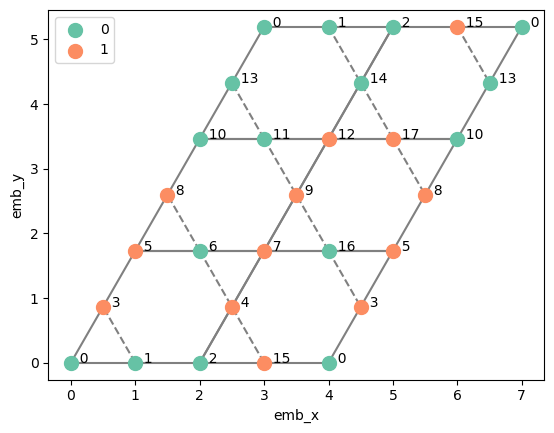

In [ ]:
lattice.plot(spins=system.canonical_basis.states[predictions.argsort()[-3]])